
========== Testing with n_qubits = 2 ==========

--- Stage 1/4: Training on original data ---
Epoch 1/25, Train Loss: 0.077925, Val Loss: 0.068260
Epoch 2/25, Train Loss: 0.062018, Val Loss: 0.055218
Epoch 3/25, Train Loss: 0.056872, Val Loss: 0.053129
Epoch 4/25, Train Loss: 0.056326, Val Loss: 0.053110
Epoch 5/25, Train Loss: 0.055298, Val Loss: 0.053340
Epoch 6/25, Train Loss: 0.055875, Val Loss: 0.057266
Epoch 7/25, Train Loss: 0.055966, Val Loss: 0.053271
Epoch 8/25, Train Loss: 0.055333, Val Loss: 0.052493
Epoch 9/25, Train Loss: 0.055540, Val Loss: 0.054259
Epoch 10/25, Train Loss: 0.055415, Val Loss: 0.054369
Epoch 11/25, Train Loss: 0.056140, Val Loss: 0.052980
Epoch 12/25, Train Loss: 0.055235, Val Loss: 0.053948
Epoch 13/25, Train Loss: 0.055528, Val Loss: 0.052911
Epoch 14/25, Train Loss: 0.055155, Val Loss: 0.052518
Epoch 15/25, Train Loss: 0.055191, Val Loss: 0.054362
Epoch 16/25, Train Loss: 0.056032, Val Loss: 0.052415
Epoch 17/25, Train Loss: 0.055192, Val Loss: 0.052

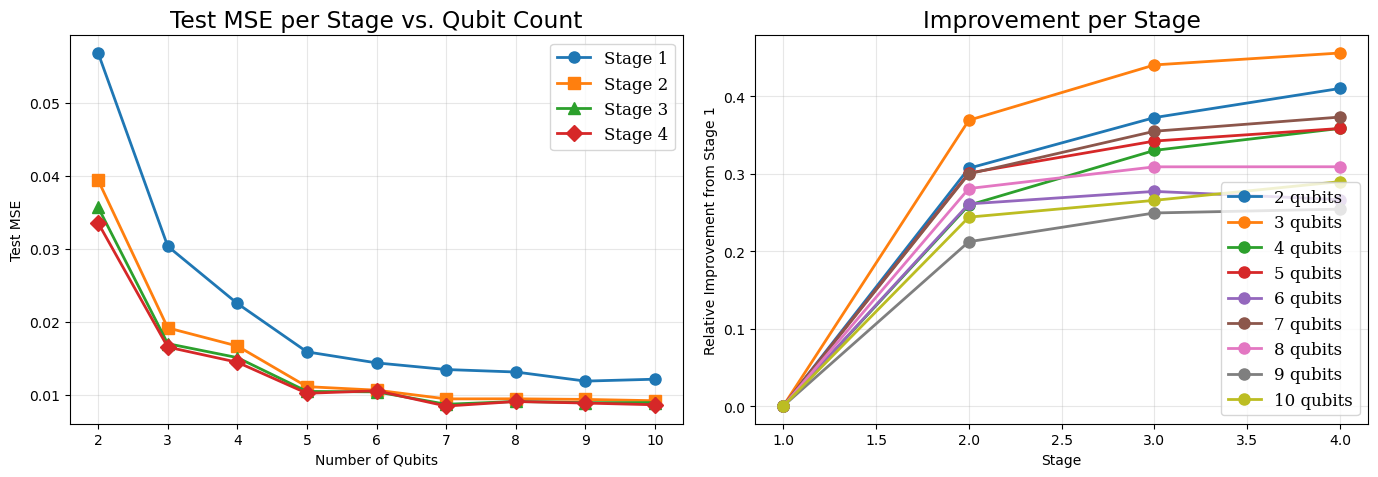

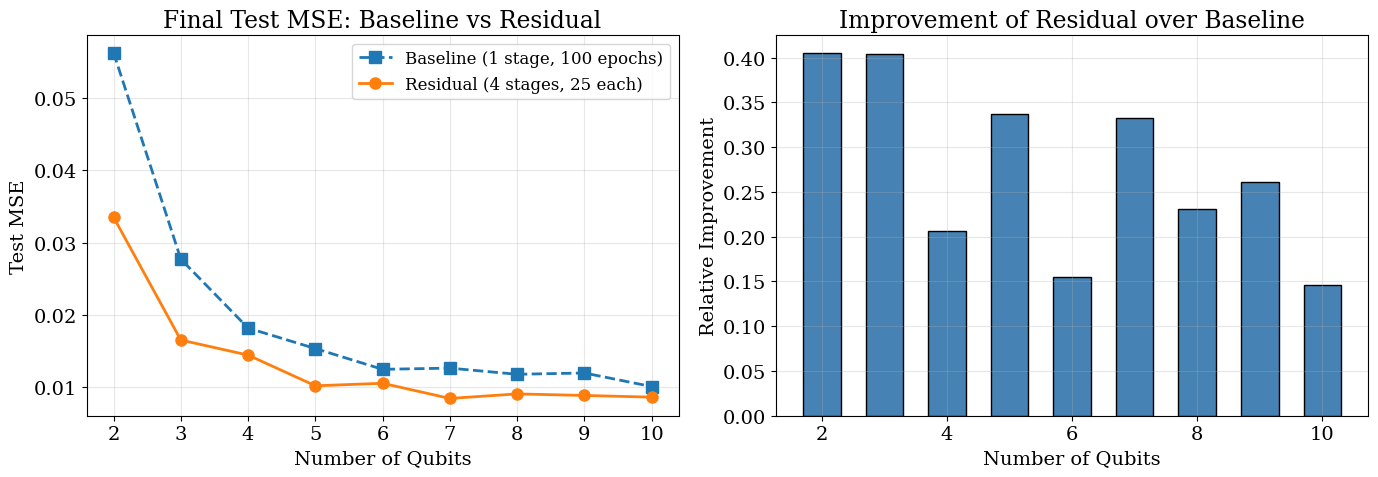

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from core import set_seed, generate_multifreq_data, load_data, ResidualQuantumLearner
import torch

# Configuration (can be adjusted)
config = {
    'seed': 42,
    'data': {
        'n_samples': 5000,
        'x_range': (0, 2.0),
        'noise': 0.0,
        'components': [
            {'freq': 0.5, 'center': 0.3, 'width': 0.2, 'amp': 1.0},
            {'freq': 3.0, 'center': 0.8, 'width': 0.15, 'amp': 0.7,
             'envelope': lambda x, c, w: 1 / (1 + ((x - c)/w)**2)},
            {'freq': 7.0, 'center': 1.2, 'width': 0.25, 'amp': 0.5,
             'envelope': lambda x, c, w: np.maximum(0, 1 - np.abs(x - c)/w)},
            {'freq': 12.0, 'center': 1.7, 'width': 0.1, 'amp': 0.3},
            {'freq': 20.0, 'center': 1.9, 'width': 0.05, 'amp': 0.2},
        ],
    },
    'training': {
        'batch_size': 64,
        'val_split': 0.15,
        'test_split': 0.15,
    },
    'model': {
        'input_dim': 1,
        'n_layers': 2,
    },
    'optim': {
        'lr': 0.005,
        'epochs': 25,
    },
    'residual': {
        'n_stages': 4,
    },
}

qubit_list = [2, 3, 4, 5, 6, 7, 8,9,10]  # adjust as needed
results = {}        # qubit -> list of MSE per stage (residual)
baseline_results = {}  # qubit -> baseline MSE (single stage, total epochs)

set_seed(config['seed'])

# Generate data once (same for all qubit counts)
X, y = generate_multifreq_data(
    n_samples=config['data']['n_samples'],
    x_range=config['data']['x_range'],
    noise=config['data']['noise'],
    components=config['data']['components'],
    random_state=config['seed']
)
train_loader, val_loader, test_loader, _, _ = load_data(
    X, y,
    batch_size=config['training']['batch_size'],
    val_split=config['training']['val_split'],
    test_split=config['training']['test_split']
)

total_epochs = config['optim']['epochs'] * config['residual']['n_stages']  # e.g. 25*4 = 100

for nq in qubit_list:
    print(f"\n========== Testing with n_qubits = {nq} ==========")
    
    # --- Residual model (4 stages, each 25 epochs) ---
    learner = ResidualQuantumLearner(
        input_dim=config['model']['input_dim'],
        n_qubits=nq,
        n_layers=config['model']['n_layers'],
        lr=config['optim']['lr'],
        epochs=config['optim']['epochs'],
        n_stages=config['residual']['n_stages']
    )
    learner.fit(train_loader, val_loader)

    X_test_t = test_loader.dataset.tensors[0]
    y_test_t = test_loader.dataset.tensors[1]
    mse_per_stage = []
    for stage in range(1, learner.n_stages + 1):
        pred = learner.predict(X_test_t, stage=stage)
        mse = torch.mean((pred - y_test_t) ** 2).item()
        mse_per_stage.append(mse)
        print(f"Stage {stage} test MSE: {mse:.6f}")
    results[nq] = mse_per_stage

    # --- Baseline model (1 stage, trained for total_epochs) ---
    print(f"\n--- Baseline (1 stage, {total_epochs} epochs) ---")
    baseline_learner = ResidualQuantumLearner(
        input_dim=config['model']['input_dim'],
        n_qubits=nq,
        n_layers=config['model']['n_layers'],
        lr=config['optim']['lr'],
        epochs=total_epochs,          # train for total_epochs
        n_stages=1
    )
    baseline_learner.fit(train_loader, val_loader)
    pred_baseline = baseline_learner.predict(X_test_t, stage=1)
    baseline_mse = torch.mean((pred_baseline - y_test_t) ** 2).item()
    baseline_results[nq] = baseline_mse
    print(f"Baseline test MSE: {baseline_mse:.6f}")

# -------------------------------------------------------------------
# Figure 1: original two subplots (MSE per stage, improvement per stage)
# -------------------------------------------------------------------
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.family'] = 'serif'

# Left: MSE for all stages vs qubit count
qubits = sorted(results.keys())
n_stages = config['residual']['n_stages']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
for stage in range(1, n_stages + 1):
    mse_at_stage = [results[q][stage-1] for q in qubits]
    axes[0].plot(qubits, mse_at_stage, marker=markers[stage-1], linestyle='-',
                 label=f'Stage {stage}')
axes[0].set_xlabel('Number of Qubits')
axes[0].set_ylabel('Test MSE')
axes[0].set_title('Test MSE per Stage vs. Qubit Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: relative improvement per stage for each qubit
for q in qubits:
    mse = results[q]
    rel_improve = [(mse[0] - m) / mse[0] for m in mse]
    axes[1].plot(range(1, n_stages+1), rel_improve, 'o-', label=f'{q} qubits')
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Relative Improvement from Stage 1')
axes[1].set_title('Improvement per Stage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('experiment_qubit_count1.png', dpi=300)
plt.savefig('experiment_qubit_count1.pdf', dpi=300)
plt.show()

# -------------------------------------------------------------------
# Figure 2: Comparison with baseline (same total epochs)
# -------------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Left: final MSE comparison
baseline_mse_list = [baseline_results[q] for q in qubits]
residual_final_mse = [results[q][-1] for q in qubits]

axes2[0].plot(qubits, baseline_mse_list, 's--', label='Baseline (1 stage, 100 epochs)', markersize=8)
axes2[0].plot(qubits, residual_final_mse, 'o-', label='Residual (4 stages, 25 each)', markersize=8)
axes2[0].set_xlabel('Number of Qubits')
axes2[0].set_ylabel('Test MSE')
axes2[0].set_title('Final Test MSE: Baseline vs Residual')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Right: relative improvement of residual over baseline
improvement = [(baseline_results[q] - results[q][-1]) / baseline_results[q] for q in qubits]
axes2[1].bar(qubits, improvement, width=0.6, color='steelblue', edgecolor='k')
axes2[1].set_xlabel('Number of Qubits')
axes2[1].set_ylabel('Relative Improvement')
axes2[1].set_title('Improvement of Residual over Baseline')
axes2[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

plt.savefig('experiment_qubit_count2.png', dpi=300)
plt.savefig('experiment_qubit_count2.pdf', dpi=300)
plt.show()

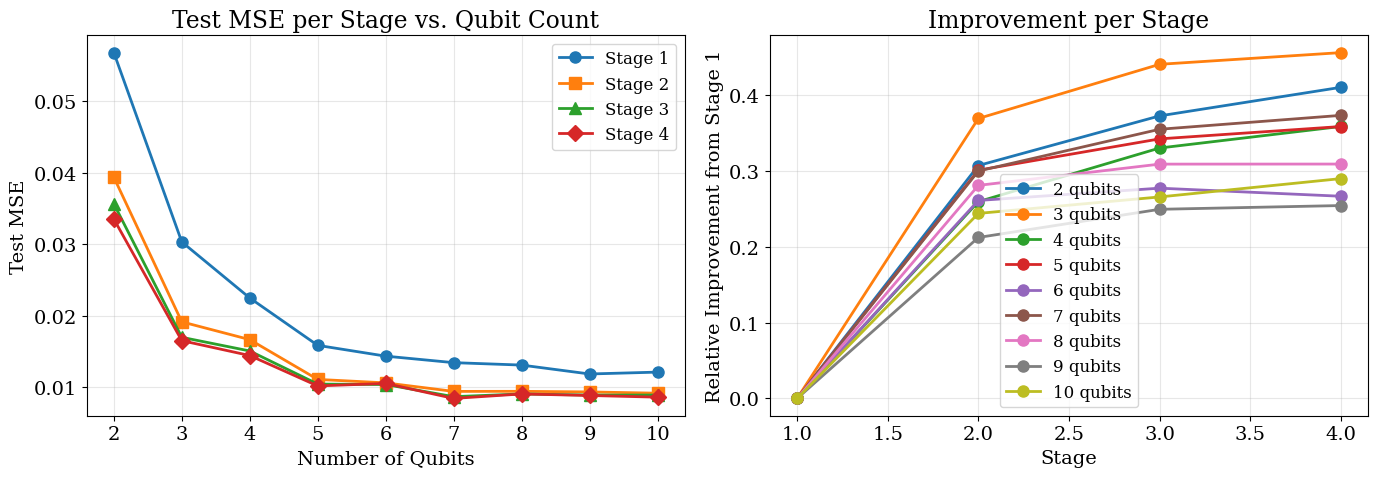

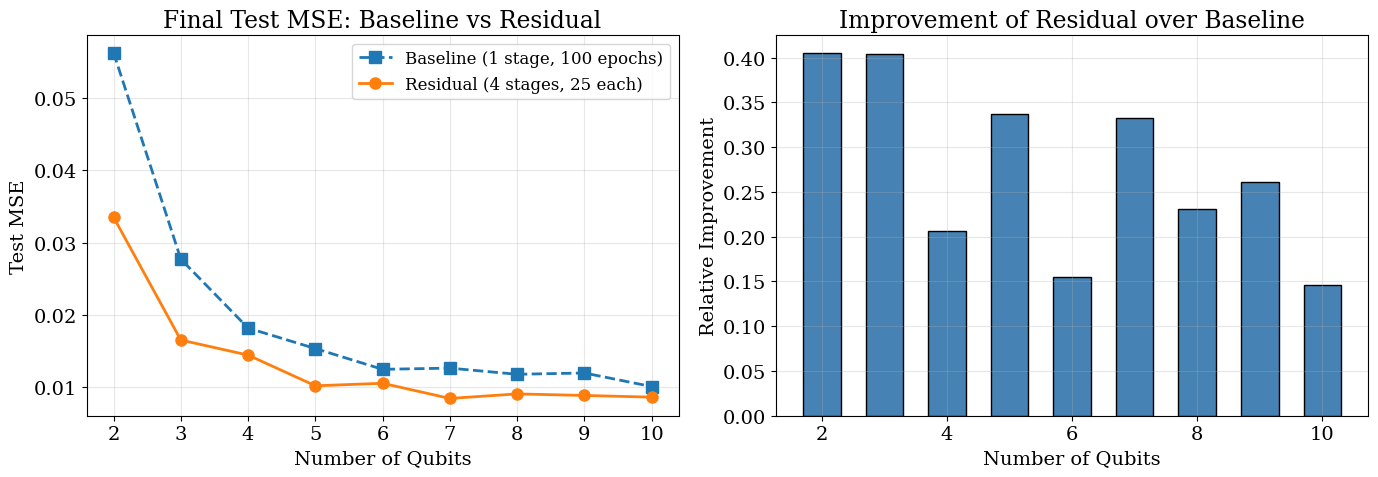

In [ ]:

# -------------------------------------------------------------------
# Figure 1: original two subplots (MSE per stage, improvement per stage)
# -------------------------------------------------------------------
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.family'] = 'serif'

# Left: MSE for all stages vs qubit count
qubits = sorted(results.keys())
n_stages = config['residual']['n_stages']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
for stage in range(1, n_stages + 1):
    mse_at_stage = [results[q][stage-1] for q in qubits]
    axes[0].plot(qubits, mse_at_stage, marker=markers[stage-1], linestyle='-',
                 label=f'Stage {stage}')
axes[0].set_xlabel('Number of Qubits')
axes[0].set_ylabel('Test MSE')
axes[0].set_title('Test MSE per Stage vs. Qubit Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: relative improvement per stage for each qubit
for q in qubits:
    mse = results[q]
    rel_improve = [(mse[0] - m) / mse[0] for m in mse]
    axes[1].plot(range(1, n_stages+1), rel_improve, 'o-', label=f'{q} qubits')
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Relative Improvement from Stage 1')
axes[1].set_title('Improvement per Stage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('experiment_qubit_count1.png', dpi=300)
plt.savefig('experiment_qubit_count1.pdf', dpi=300)
plt.show()

# -------------------------------------------------------------------
# Figure 2: Comparison with baseline (same total epochs)
# -------------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.family'] = 'serif'

# Left: final MSE comparison
baseline_mse_list = [baseline_results[q] for q in qubits]
residual_final_mse = [results[q][-1] for q in qubits]

axes2[0].plot(qubits, baseline_mse_list, 's--', label='Baseline (1 stage, 100 epochs)', markersize=8)
axes2[0].plot(qubits, residual_final_mse, 'o-', label='Residual (4 stages, 25 each)', markersize=8)
axes2[0].set_xlabel('Number of Qubits')
axes2[0].set_ylabel('Test MSE')
axes2[0].set_title('Final Test MSE: Baseline vs Residual')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Right: relative improvement of residual over baseline
improvement = [(baseline_results[q] - results[q][-1]) / baseline_results[q] for q in qubits]
axes2[1].bar(qubits, improvement, width=0.6, color='steelblue', edgecolor='k')
axes2[1].set_xlabel('Number of Qubits')
axes2[1].set_ylabel('Relative Improvement')
axes2[1].set_title('Improvement of Residual over Baseline')
axes2[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

plt.savefig('experiment_qubit_count2.png', dpi=300)
plt.savefig('experiment_qubit_count2.pdf', dpi=300)
plt.show()


In [ ]:
baseline_mse

0.010067131370306015

In [ ]:
baseline_results

{2: 0.056329574435949326,
 3: 0.02772171050310135,
 4: 0.018169257789850235,
 5: 0.015330241061747074,
 6: 0.012451325543224812,
 7: 0.012619192712008953,
 8: 0.0117653151974082,
 9: 0.011945570819079876,
 10: 0.010067131370306015}

In [ ]:
improvement

[0.40472149227011306,
 0.4044861311377157,
 0.20604434076173303,
 0.3365466190697236,
 0.1552205843909451,
 0.3327899286739871,
 0.2310718408449169,
 0.260630155212752,
 0.1459925065914242]

In [ ]:
baseline_mse_list

[0.056329574435949326,
 0.02772171050310135,
 0.018169257789850235,
 0.015330241061747074,
 0.012451325543224812,
 0.012619192712008953,
 0.0117653151974082,
 0.011945570819079876,
 0.010067131370306015]

In [ ]:
residual_final_mse

[0.033531785011291504,
 0.016508663073182106,
 0.01442558504641056,
 0.010170900262892246,
 0.010518623515963554,
 0.008419652469456196,
 0.00904668215662241,
 0.008832194842398167,
 0.00859740562736988]